## ESG Factors

### How LSEG Creates Factors
URL: https://wrds-www.wharton.upenn.edu/pages/get-data/lseg/refinitiv-esg/refinitiv-esg-scores/#dataDictionaryTab

There are many different boxes they are looking to check for each measure. Each of these boxes are either assigned a boolean or numeric value, These boxes are all industry specific. Each of these boxes or targets have been pre defined by LSEG, and they have anywhere from 20-50 per category. 

PIC

Then, percentile score calculation formulas are applied for each measure. Similar to the boxes being industry specific, the overall percentile score is calculated within each industry as well. This determines the smaller category scores, and then pillar scores are calculated as the weighted sum. 


### Factor Descriptions
- **ESG Workforce Factor**: The workforce score measures a company’s effectiveness in terms of providing job satisfaction, a healthy and safe workplace, maintaining diversity and equal opportunities, and development opportunities for its workforce. 
- **ESG Management Factor**: Management category score measures a company's commitment and effectiveness towards following best practice corporate governance principles.
- **ESG Product Responsibility Score**: Product responsibility category score reflects a company's capacity to produce quality goods and services integrating the customer's health and safety, integrity and data privacy.
- **ESG Resource Use Score**: Resource use category score reflects a company's performance and capacity to reduce the use of materials, energy or water, and to find more eco-efficient solutions by improving supply chain management.
- **ESG Score**: Refinitiv's ESG Score is an overall company score based on the self-reported information in the environmental, social and corporate governance pillars.
- **ESG Shareholders Score**: Shareholders category score measures a company's effectiveness towards equal treatment of shareholders and the use of anti-takeover devices.
- **ESGC Controversies Score**: ESG controversies category score measures a company's exposure to environmental, social and governance controversies and negative events reflected in global media. 
- **ESG Combined Score**: Refinitiv's ESG Combined Score is an overall company score based on the reported information in the environmental, social and corporate governance pillars (ESG Score) with an ESG Controversies overlay.
- **ESG Community Score**: Community category score measures the company's commitment towards being a good citizen, protecting public health and respecting business ethics.
- **ESG Csr Strategy Score**: CSR strategy category score reflects a company's practices to communicate that it integrates the economic (financial), social and environmental dimensions into its day-to-day decision-making processes.
- **ESG Emissions Score**: Emission category score measures a company's commitment and effectiveness towards reducing environmental emission in the production and operational processes.
- **ESG Human Rights Score**: Human rights category score measures a company's effectiveness towards respecting the fundamental human rights conventions.
- **ESG Innovation Score**: Environmental innovation category score reflects a company's capacity to reduce the environmental costs and burdens for its customers, and thereby creating new market opportunities through new environmental technologies and processes or eco-designed products.


### Misc. Notes

tqdm wrapper, wrap the for loop. 
on comment line, can run the profiler. C profile. can give an actually time spent for each line. 
python cProfile -m your_code.py

In [ ]:
import pandas as pd
import warnings
from pathlib import Path
import wrds
from settings import config

FAMA_DATA_DIR = config("OUTPUT_DIR")
DATA_DIR      = config('DATA_DIR')
START_DATE    = pd.Timestamp(config("START_DATE"))
END_DATE      = pd.Timestamp(config("END_DATE"))
WRDS_USERNAME = config("WRDS_USERNAME")

db = wrds.Connection(wrds_username=WRDS_USERNAME)
def pull_esg(n: int,
             years = range(2020, 2025),
             cache_returns_path: Path = None) -> pd.DataFrame:
    """
    Build ESG long-short factor indices:
      - For each metric (fieldname) and each year, pick top-n percent (long) and bottom-n percent (short) tickers by valuescore.
      - Compute equal-weight L/S returns for that year and metric.
    Returns a DataFrame indexed by date with one column per ESG metric.
    """
    if cache_returns_path is None:
        cache_returns_path = DATA_DIR / 'daily_returns.parquet'

    warnings.filterwarnings('ignore')

    tickers = list(pd.read_csv(DATA_DIR / 'russell_2000_tickers.csv')['AAMI'])

    db = wrds.Connection(wrds_username=WRDS_USERNAME)
    try:

        in_list = ','.join([f"'{t}'" for t in tickers])

        esg_query = f"""
            SELECT
                year,
                ticker,
                fieldid,
                hierarchy,
                pillar,
                fieldname,
                valuedate,
                value,
                valuescore
            FROM tresg.wrds_ref_esg
            WHERE ticker IN ({in_list})
              AND year BETWEEN 2020 AND 2025
              AND fieldid IN (
                   1,  2,  3,  4,  5,  6,  7,  8,
                   9, 10, 11, 12, 13, 14, 15, 16
              )
            ORDER BY year, fieldid
        """
        esg = db.raw_sql(esg_query)

        annual = (
            esg.pivot_table(index=['year', 'ticker'],
                            columns='fieldname',
                            values='valuescore',
                            aggfunc='mean')
        )


        top_dict, bot_dict = {}, {}
        size = round(len(tickers)/n)

        for col in annual.columns:
            s = annual[col].dropna()
            for year, grp in s.groupby(level='year'):
                # drop the 'year' level so index is just 'ticker'
                grp_t = grp.reset_index(level='year', drop=True)
                top_dict[(year, col)] = grp_t.nlargest(size)
                bot_dict[(year, col)] = grp_t.nsmallest(size)

        top_df = (
            pd.concat(top_dict, names=['year', 'metric'])
            .rename('score')              
            .reset_index()                # columns =  year, metric, ticker, score
        )
        bot_df = (
            pd.concat(bot_dict, names=['year', 'metric'])
            .rename('score')
            .reset_index()
)


        # Pairs by rank position
        top_df['pos'] = top_df.groupby(['year','metric']).cumcount()
        bot_df['pos'] = bot_df.groupby(['year','metric']).cumcount()

        pairs = (
            top_df.merge(bot_df,
                        on=['year', 'metric', 'pos'],
                        suffixes=('u', 'd'))
                .drop(columns=['pos', 'scoreu', 'scored'])
                .sort_values(['year', 'metric'])
        )
        all_tickers = sorted(set(pairs['tickeru']) | set(pairs['tickerd']))

        if cache_returns_path.exists():
            returns_df = pd.read_parquet(cache_returns_path)
            returns_df['date'] = pd.to_datetime(returns_df['date'])
            returns_df = returns_df.set_index('date').sort_index()
        else:
            in_list_r = ','.join([f"'{t}'" for t in all_tickers])
            ret_query = f"""
                SELECT dlycaldt AS date, ticker, dlyret
                FROM crsp.dsf_v2
                WHERE dlycaldt BETWEEN '{START_DATE:%Y-%m-%d}' AND '{END_DATE:%Y-%m-%d}'
                AND ticker IN ({in_list_r})
            """
            crsp = db.raw_sql(ret_query)
            crsp['date'] = pd.to_datetime(crsp['date'])

            returns_df = (
                crsp.pivot_table(index='date', columns='ticker', values='dlyret')
                    .sort_index()
            )
            returns_df.to_parquet(cache_returns_path)


        metrics = pairs['metric'].unique()
        index_df = pd.DataFrame(index=returns_df.index, columns=metrics, dtype=float)

        for (year, metric), grp in pairs.groupby(['year', 'metric']):

            mask = returns_df.index.year == year
            long_tickers  = [str(t).strip().upper() for t in grp['tickeru'].tolist()]
            short_tickers = [str(t).strip().upper() for t in grp['tickerd'].tolist()]

            sub = returns_df.loc[mask, :]  # rows for this calendar year

            long_block  = sub.reindex(columns=long_tickers)
            short_block = sub.reindex(columns=short_tickers)

            if long_block.shape[1] == 0 or short_block.shape[1] == 0:
                continue

            long_mean  = long_block.mean(axis=1)   
            short_mean = short_block.mean(axis=1)
            index_df.loc[mask, metric] = long_mean - short_mean


            index_df.loc[mask, metric] = long_mean - short_mean

        index_df = index_df.dropna(how='all')  

        return index_df

    finally:
        db.close()

def performance_check(n):
    """
    n = Maximum portfolio size to evaluate (will test 10, 20, ..., n).

    best_size = The portfolio size with the lowest sum of ranks.
    rank_sums = Sum of factor‐ranks for each size (index = size).
    ranks_df = The full ranking table (rows = size, cols = factor names).
    """

    sizes = list(range(10, n + 1, 10))

    perf_dict = {}
    for size in sizes:
        returns = pull_esg(size)                  
        cumul   = (returns + 1).cumprod() - 1     
        last    = cumul.iloc[-1].abs()            
        perf_dict[size] = last

    perf_df = pd.DataFrame(perf_dict).T          

    # Here, we rank all of the factors within the dataframe from the smallest to the largest. Then we will go through and sum them to see which had the best overall performance. 

    ranks_df = perf_df.rank(axis=1, ascending=False, method="min")

    rank_sums = ranks_df.sum(axis=1)

    best_size = rank_sums.idxmin()

    best_performing = pull_esg(int(best_size))

    print("Sum of ranks by size:\n", rank_sums, "\n")
    print(f"Best performing portfolio size is {best_size}")

    return best_size, rank_sums, ranks_df, best_performing



best_size, rank_sums, rank_df, best_performing = performance_check(40)
best_size

    # salrego


WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
ESGCControversiesScore           1.009608
ESGCombinedScore                 0.400708
ESGCommunityScore                0.584756
ESGCsrStrategyScore              0.633260
ESGEmissionsScore                0.385730
ESGHumanRightsScore              0.657897
ESGInnovationScore               0.497597
ESGManagementScore               0.628423
ESGProductResponsibilityScore    0.104300
ESGResourceUseScore              0.502621
ESGScore                         0.569050
ESGShareholdersScore             0.138263
ESGWorkforceScore                0.476134
EnvironmentPillarScore           0.645097
GovernancePillarScore            0.624469
SocialPillarScore                0.516569
Name: 2024-12-31 00:00:00, dtype: float64
ESGCControversiesScore           2.719820
ESGCombinedScore                 0.551094
ESGCommunityScore                0.503254
ES

40

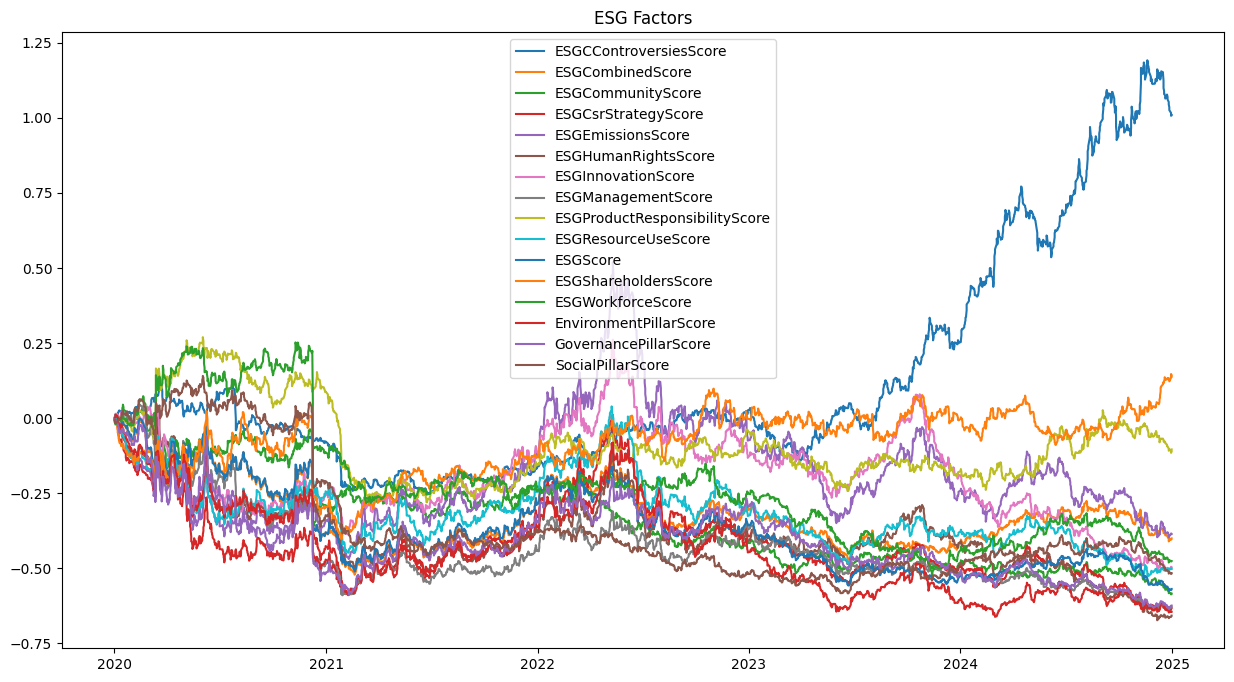

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
plt.title('ESG Factors')
for col in output:
    plt.plot((1+output[col]).cumprod() - 1, label = col)
plt.legend()
plt.show()


### Stationary Tests

In [ ]:
# ADF Test should be conducted twice, first when we have the raw series, and second after we take diff()
# How to detect if there is an overall trend to the data without doing it manually. 
# Daily returns for the SQL query, see the other jupyter notebook. 
# Refer to MSA notes for lambda parameter tuning. 
# for the grid search we will evaluate via IC or sharpe. 
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from settings import config
import pandas as pd 
import numpy as np

def adf_test(df,map_df,trend_id = None,alpha=0.05, second_pass = False ):
    # Divide series into one that has a trend and one that does not. 
    # After differencing we should be running adf on regression ='c'
    
    cols = ['ADF','pvalue','usedlag','nobs','critical_values','icbest']

    adf_df = pd.DataFrame(columns = cols)
    for id in df.columns.tolist():
        series = df[id].dropna()

        if second_pass:
            reg = 'c'
        else: 
            reg = 'ct' if trend_id is not None and id in trend_id else 'c'
        try:
            result = adfuller(series, regression=reg, maxlag=1, autolag = 't-stat')
            adf, pval, lag, nobs, crit_vals, icbest = result
            cv = crit_vals[f"{int(alpha*100)}%"]
            adf_df.loc[id] = [adf,pval,lag,nobs,cv,icbest]

        except Exception as e:
            print(f"[{id}] ADF test failed: {e}")
            continue

    adf_df['null'] = np.where(adf_df['pvalue']<alpha,True,False) # if it's true then its stationary
    # adf_df['desc'] = adf_df.index.map(map_df.set_index('id')['title'])
    # adf_df['units_short'] = adf_df.index.map(map_df.set_index('id')['units_short'])
    adf_df = adf_df.sort_values(by='pvalue',ascending=False)
    return adf_df 

def difference(df,adf_df):
    # Difference the series if not stationary. Log differencing for levels and differencing for rates.
    # If adf test is rejected then we are accepting hypothesis that it is stationary.

    filter_rates_id = adf_df[~(adf_df['null']) & (adf_df['units_short'].str.contains('%'))].index
    filter_level_id = adf_df[~(adf_df['null']) & (~adf_df['units_short'].str.contains('%'))].index

    # Real Gross Domestic Product, Real gross domestic product per capita, Real Potential Gross Domestic Product
    # Check

    for id in df.columns:
        df_clean = df[id].dropna()
        if id in filter_rates_id:
            df[id] = df_clean.diff().reindex(df.index)
        elif id in filter_level_id:
            df[id] = np.log(df_clean).diff().reindex(df.index)
        else: 
            df[id] = df_clean.reindex(df.index)

    return df




In [20]:
ESG = pd.read_parquet(r'C:\Users\SalRe\OneDrive\Documents\GitHub\MSFM\Summer Externship\FactorAnalysis\_data\ESG_factors.parquet')
mapdf = pd.DataFrame()
output = adf_test(ESG,mapdf)
final = difference(ESG, output)
output

,ADF,pvalue,usedlag,nobs,critical_values,icbest,null
ESGCControversiesScore,-23.666771,0.0,1.0,1256.0,-2.863844,1.886908,True
ESGCombinedScore,-37.208213,0.0,0.0,1257.0,-2.863842,37.193376,True
ESGCommunityScore,-40.070614,0.0,0.0,1257.0,-2.863842,40.062418,True
ESGCsrStrategyScore,-35.835745,0.0,0.0,1257.0,-2.863842,35.824333,True
ESGEmissionsScore,-34.566398,0.0,0.0,1257.0,-2.863842,34.537833,True
ESGHumanRightsScore,-35.951274,0.0,0.0,1257.0,-2.863842,35.933606,True
ESGInnovationScore,-35.109472,0.0,0.0,1257.0,-2.863842,35.095263,True
ESGManagementScore,-34.593524,0.0,0.0,1257.0,-2.863842,34.568927,True
ESGProductResponsibilityScore,-34.105219,0.0,0.0,1257.0,-2.863842,34.087386,True
ESGResourceUseScore,-26.489830,0.0,1.0,1256.0,-2.863844,1.683250,True
